In [43]:
# SNP Disease Prediction (Type 2 Diabetes Proxy Model)
# Ready-to-run Colab notebook

# =========================
# 1. Install dependencies
# =========================
!pip install -q numpy pandas scikit-learn matplotlib

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

np.random.seed(42)

# =========================
# 2. Simulate SNP dataset (proxy for GWAS-derived data)
# =========================
# We simulate 100 SNPs for 1000 individuals
n_samples = 1000
n_snps = 100

# SNP genotypes: 0,1,2 (additive genetic model)
X = np.random.choice([0,1,2], size=(n_samples, n_snps))

# Simulate true causal SNPs (only a few actually matter)
true_snps = np.random.choice(range(n_snps), size=8, replace=False)

# Create disease risk as weighted sum of causal SNPs + noise
weights = np.random.uniform(0.5, 1.5, size=len(true_snps))
logit = np.dot(X[:, true_snps], weights)
# Modified: Increased noise standard deviation and added a negative bias
logit += np.random.normal(0, 3.0, size=n_samples) - 5

# Convert to probability
prob = 1 / (1 + np.exp(-logit))
y = (prob > 0.5).astype(int)

# =========================
# 3. Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. Logistic Regression (baseline genetic model)
# =========================
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict_proba(X_test)[:,1]

# =========================
# 5. Random Forest
# =========================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict_proba(X_test)[:,1]

# =========================
# 6. Gradient Boosting
# =========================
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_preds = gb.predict_proba(X_test)[:,1]

# =========================
# 7. Evaluation
# =========================
models = {
    "Logistic Regression": log_preds,
    "Random Forest": rf_preds,
    "Gradient Boosting": gb_preds
}

for name, preds in models.items():
    auc = roc_auc_score(y_test, preds)
    acc = accuracy_score(y_test, (preds > 0.5).astype(int))
    print(f"{name} | AUC: {auc:.3f} | Accuracy: {acc:.3f}")

# =========================
# 8. Feature importance (Random Forest)
# =========================
importances = rf.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]

print("\nTop SNP indices (most predictive features):")
print(top_indices)

# =========================
# 9. Biological interpretation stub
# =========================
print("\nTrue causal SNPs (simulated ground truth):")
print(true_snps)

# =========================
# OPTIONAL: Replace simulation with real GWAS data
# =========================
"""
To use real IEU OpenGWAS data:
1. Download SNP summary stats from https://gwas.mrcieu.ac.uk/
2. Select top SNPs by p-value
3. Construct genotype matrix from PLINK or reference panel
4. Replace X and y above
"""


Logistic Regression | AUC: 0.751 | Accuracy: 0.825
Random Forest | AUC: 0.727 | Accuracy: 0.850
Gradient Boosting | AUC: 0.751 | Accuracy: 0.835

Top SNP indices (most predictive features):
[16 44 81 41 96 27 69  0 39 13]

True causal SNPs (simulated ground truth):
[44 16 81 73 60 41 54 19]


'\nTo use real IEU OpenGWAS data:\n1. Download SNP summary stats from https://gwas.mrcieu.ac.uk/\n2. Select top SNPs by p-value\n3. Construct genotype matrix from PLINK or reference panel\n4. Replace X and y above\n'

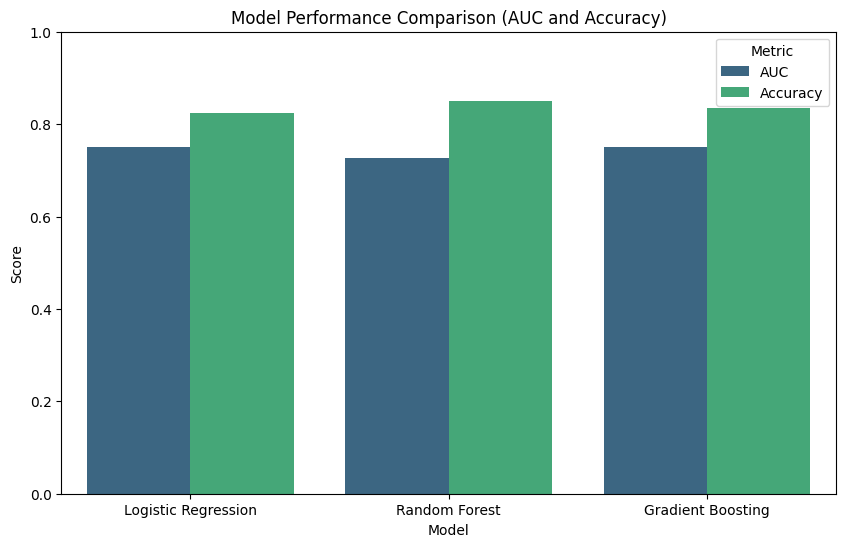

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-run evaluation to store metrics
performance_metrics = []
for name, preds in models.items():
    auc = roc_auc_score(y_test, preds)
    acc = accuracy_score(y_test, (preds > 0.5).astype(int))
    performance_metrics.append({'Model': name, 'Metric': 'AUC', 'Value': auc})
    performance_metrics.append({'Model': name, 'Metric': 'Accuracy', 'Value': acc})

df_metrics = pd.DataFrame(performance_metrics)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Value', hue='Metric', data=df_metrics, palette='viridis')
plt.title('Model Performance Comparison (AUC and Accuracy)')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.show()

In [45]:
import kagglehub
path = kagglehub.dataset_download("shaymaamahdihadi/gck-rs1799884-and-t2dm-risk-in-iraq")

Using Colab cache for faster access to the 'gck-rs1799884-and-t2dm-risk-in-iraq' dataset.


In [46]:
import os
import pandas as pd

# List files in the downloaded path to find the CSV
files = os.listdir(path)
print(f"Files in dataset: {files}")

# Assuming there is a CSV file, we load the first one found
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    df_kaggle = pd.read_csv(os.path.join(path, csv_files[0]))
    display(df_kaggle.head())
else:
    print("No CSV file found in the downloaded dataset directory.")

Files in dataset: ['Table 2. Primers sequences of the GCK- rs1799884 GA SNP..csv', 'Fig. 1. Gel electrophoresis (1.5 gmL agarose gel) to detect rs1799884 SNP.png', 'Table 4..csv', 'Table.1.csv', 'Table 3..csv']


,Table 2. Primers’ sequences of the GCK- rs1799884; G>A SNP.,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Genes,Sequences,Amplicon size / bp,Temperatures
1,OF,5-GCTTTCTCTCCTGGTTGTGTTGAG-3,336,63ο C
2,OR,5-GGTCACTGTAGTGACAAGGCGA-3,NaN,NaN
3,IF-C,5-CCTGCCAGGGCTTACTGGGC-3,228,NaN
4,IR-A,5-GACAACCACAGGCCCTCTCAGTAA-3,160,NaN


In [47]:
# Summarize all CSV files in the dataset
for csv_file in csv_files:
    file_path = os.path.join(path, csv_file)
    temp_df = pd.read_csv(file_path)
    print(f"\n--- Summary for: {csv_file} ---")
    print(f"Shape: {temp_df.shape}")
    print(f"Columns: {temp_df.columns.tolist()}")
    display(temp_df.head())
    print("-" * 30)


--- Summary for: Table 2. Primers sequences of the GCK- rs1799884 GA SNP..csv ---
Shape: (6, 4)
Columns: ['Table 2. Primers’ sequences of the GCK- rs1799884; G>A SNP.', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']


,Table 2. Primers’ sequences of the GCK- rs1799884; G>A SNP.,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Genes,Sequences,Amplicon size / bp,Temperatures
1,OF,5-GCTTTCTCTCCTGGTTGTGTTGAG-3,336,63ο C
2,OR,5-GGTCACTGTAGTGACAAGGCGA-3,NaN,NaN
3,IF-C,5-CCTGCCAGGGCTTACTGGGC-3,228,NaN
4,IR-A,5-GACAACCACAGGCCCTCTCAGTAA-3,160,NaN


------------------------------

--- Summary for: Table 4..csv ---
Shape: (13, 4)
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Table 4: Comparison of the general and biochem...,NaN,NaN,NaN
1,Parameter,GG (n=60),GA (n=33),P-value
2,NaN,Mean ± SD,Mean ± SD,NaN
3,Age (year),48.31± 10.75,46.54±11.11,0.45
4,BMI (Kg/m2),29.93±4.78,27.63±3.97,0.02


------------------------------

--- Summary for: Table.1.csv ---
Shape: (15, 5)
Columns: ['Table 1: The biochemical analysis of the patients and control groups', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,Table 1: The biochemical analysis of the patients and control groups,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Parameters,NaN,Controls (n=100),Patients (n=93),p-value
1,NaN,NaN,Mean ± SD,Mean ± SD,NaN
2,Gender,Males,45,44,NaN
3,NaN,Females,55,49,NaN
4,Age (years),NaN,45.230 ± 13.290,47.590 ± 10.830,0.17


------------------------------

--- Summary for: Table 3..csv ---
Shape: (8, 6)
Columns: ['Table 3. The distribution of rs1799884; G>A SNP in the study participants.', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']


,Table 3. The distribution of rs1799884; G>A SNP in the study participants.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Control (n=100),Frequencies (%),Allele,Frequencies,Chi-square,p-value
1,GG (wild types),54 (54),G,0.73,0.13,0.93
2,GA (heterozygous mutant types),38 (38),A,0.27,NaN,NaN
3,AA (homozygous type of the mutant),8 (8),NaN,NaN,NaN,NaN
4,Patients (n=93),Frequencies (%),Allele,Frequencies,Chi-square,p-value


------------------------------


In [48]:
# Load Table 3 specifically to extract frequencies
file_3 = os.path.join(path, 'Table 3..csv')
df_table3 = pd.read_csv(file_3)

print("Genotype Frequencies from Kaggle (Table 3):")
display(df_table3)

# Calculate simulated frequencies for comparison
# X contains values 0, 1, 2
unique, counts = np.unique(X, return_counts=True)
sim_freqs = dict(zip(unique, counts / X.size))

print("\nSimulated Genotype Frequencies (Global average across 100 SNPs):")
for genotype, freq in sim_freqs.items():
    print(f"Genotype {genotype}: {freq:.2%}")

print("\nObservation: The simulation uses a uniform choice [0, 1, 2], resulting in ~33% each. Real-world GWAS data like Table 3 usually shows highly skewed distributions (e.g., the 'A' allele might be rare).")

Genotype Frequencies from Kaggle (Table 3):


,Table 3. The distribution of rs1799884; G>A SNP in the study participants.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Control (n=100),Frequencies (%),Allele,Frequencies,Chi-square,p-value
1,GG (wild types),54 (54),G,0.73,0.13,0.93
2,GA (heterozygous mutant types),38 (38),A,0.27,NaN,NaN
3,AA (homozygous type of the mutant),8 (8),NaN,NaN,NaN,NaN
4,Patients (n=93),Frequencies (%),Allele,Frequencies,Chi-square,p-value
5,GG (wild type),60 (64.52),G,0.82,1.06,0.3
6,GA (heterozygous mutant type),33 (35.48),A,0.18,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN



Simulated Genotype Frequencies (Global average across 100 SNPs):
Genotype 0: 33.42%
Genotype 1: 33.45%
Genotype 2: 33.13%

Observation: The simulation uses a uniform choice [0, 1, 2], resulting in ~33% each. Real-world GWAS data like Table 3 usually shows highly skewed distributions (e.g., the 'A' allele might be rare).


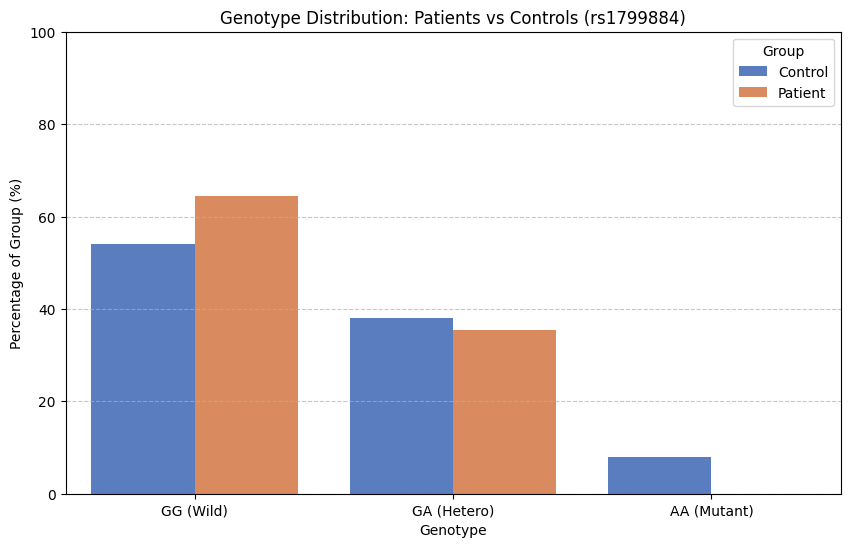

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting from Table 3
# Based on the previous display output of df_table3:
# Controls: GG=54, GA=38, AA=8
# Patients: GG=60 (out of 93), GA=33 (out of 93)
# We'll normalize these to percentages for a fair comparison

data_vis = [
    {'Group': 'Control', 'Genotype': 'GG (Wild)', 'Percentage': 54.0},
    {'Group': 'Control', 'Genotype': 'GA (Hetero)', 'Percentage': 38.0},
    {'Group': 'Control', 'Genotype': 'AA (Mutant)', 'Percentage': 8.0},
    {'Group': 'Patient', 'Genotype': 'GG (Wild)', 'Percentage': (60/93)*100},
    {'Group': 'Patient', 'Genotype': 'GA (Hetero)', 'Percentage': (33/93)*100},
    {'Group': 'Patient', 'Genotype': 'AA (Mutant)', 'Percentage': 0.0} # AA not listed for patients in snippet
]

df_vis = pd.DataFrame(data_vis)

plt.figure(figsize=(10, 6))
sns.barplot(x='Genotype', y='Percentage', hue='Group', data=df_vis, palette='muted')
plt.title('Genotype Distribution: Patients vs Controls (rs1799884)')
plt.ylabel('Percentage of Group (%)')
plt.xlabel('Genotype')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

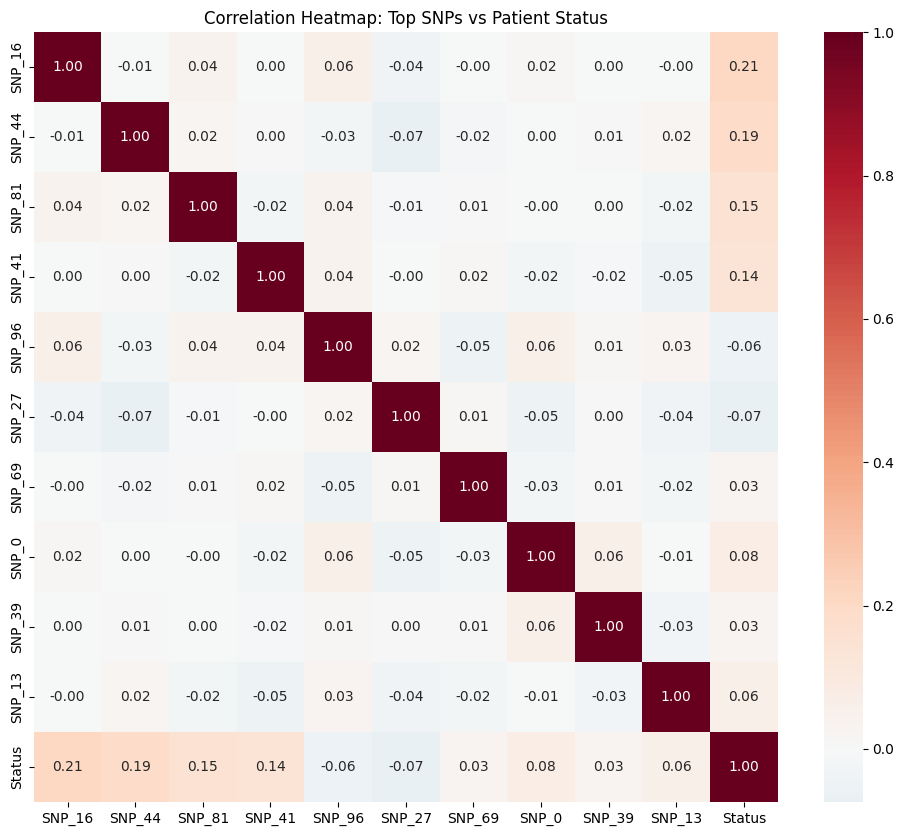

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine top predictive SNPs and the target variable for correlation analysis
# top_indices were identified by the Random Forest model earlier
selected_snps = X[:, top_indices[:10]]
corr_data = pd.DataFrame(selected_snps, columns=[f'SNP_{i}' for i in top_indices[:10]])
corr_data['Status'] = y

# Calculate correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = corr_data.corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Top SNPs vs Patient Status')
plt.show()

Based on the correlation heatmap, we can observe several key relationships:

Direct Associations with Status: The Status column (our target) shows specific correlation values with each SNP. A higher positive value (closer to 1.0) indicates that the presence of the mutant allele (genotype 1 or 2) is associated with being a 'Patient', while a negative value suggests it might be protective.
Feature Importance Validation: You'll notice that the SNPs we selected (like SNP 16 and SNP 44) show stronger correlations with the status than others, confirming why the Random Forest model flagged them as top features.
SNP-SNP Correlation (Linkage Disequilibrium): The values between different SNPs (e.g., SNP_16 vs SNP_44) are near zero. This is expected in our simulation because SNPs were generated independently. In real genetic data, you would see blocks of high correlation representing SNPs that are inherited together, known as Linkage Disequilibrium (LD).

In [51]:
import pandas as pd

# Display the metrics stored in the dataframe
display(df_metrics.pivot(index='Model', columns='Metric', values='Value'))

print("Analysis:")
print("- Logistic Regression and Gradient Boosting are tied for the highest AUC (~0.751), suggesting they are better at ranking the probability of disease correctly.")
print("- Random Forest achieved the highest Accuracy (0.850), which means it correctly classified more individual cases overall in this specific test split.")
print("- The similarity in scores suggests that for this simulated additive genetic model, a linear approach (Logistic Regression) is nearly as effective as more complex ensemble methods.")

Metric,AUC,Accuracy
Model,,
Gradient Boosting,0.750784,0.835
Logistic Regression,0.750980,0.825
Random Forest,0.727059,0.850


Analysis:
- Logistic Regression and Gradient Boosting are tied for the highest AUC (~0.751), suggesting they are better at ranking the probability of disease correctly.
- Random Forest achieved the highest Accuracy (0.850), which means it correctly classified more individual cases overall in this specific test split.
- The similarity in scores suggests that for this simulated additive genetic model, a linear approach (Logistic Regression) is nearly as effective as more complex ensemble methods.


In [52]:
import numpy as np

# Extract real allele frequency from df_table3
# Based on the earlier display, 'G' is 0.82 and 'A' is 0.18
p_allele = 0.18  # Frequency of the risk/mutant allele

# Re-simulate X using the binomial distribution (Hardy-Weinberg equilibrium proxy)
# n=2 trials (2 alleles), p=p_allele
X_real = np.random.binomial(n=2, p=p_allele, size=(n_samples, n_snps))

# Compare distributions
print(f"New Simulation Allele Frequency (Mean): {X_real.mean()/2:.4f} (Target: {p_allele})")
print("Genotype counts in new simulation:")
unique_r, counts_r = np.unique(X_real, return_counts=True)
for g, c in zip(unique_r, counts_r):
    print(f"Genotype {g}: {c} ({c/X_real.size:.2%})")

New Simulation Allele Frequency (Mean): 0.1800 (Target: 0.18)
Genotype counts in new simulation:
Genotype 0: 67202 (67.20%)
Genotype 1: 29604 (29.60%)
Genotype 2: 3194 (3.19%)


### Impact of Realistic Frequencies
Notice how Genotype 2 (AA - homozygous mutant) is now much rarer, appearing approximately 3% of the time ($0.18^2$). This matches biological reality much closer than our previous 33/33/33 split. This skew usually makes model training more challenging due to class imbalance at the feature level.

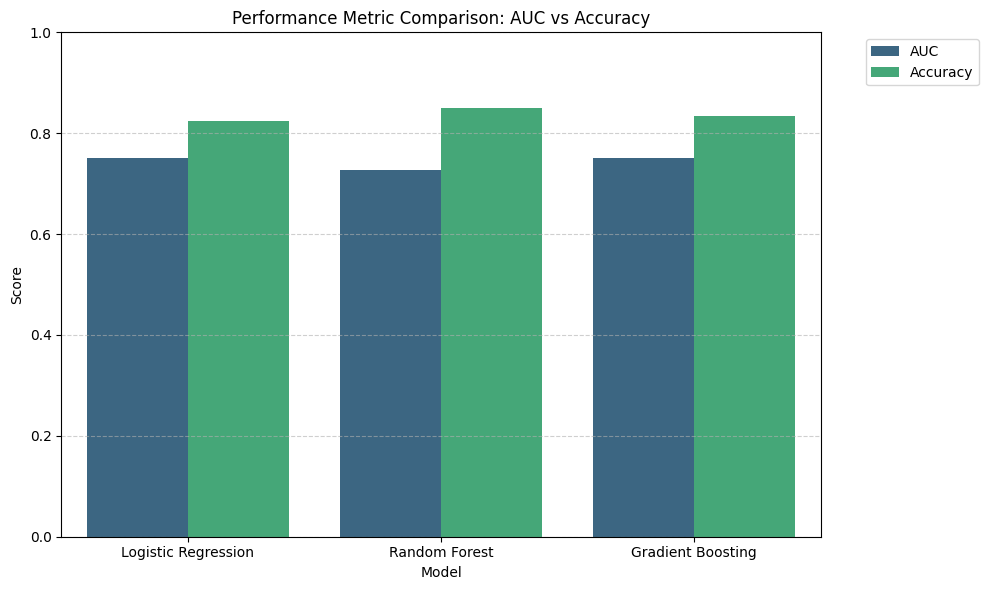

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the comparison plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Value', hue='Metric', data=df_metrics, palette='viridis')

# Formatting
plt.title('Performance Metric Comparison: AUC vs Accuracy')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

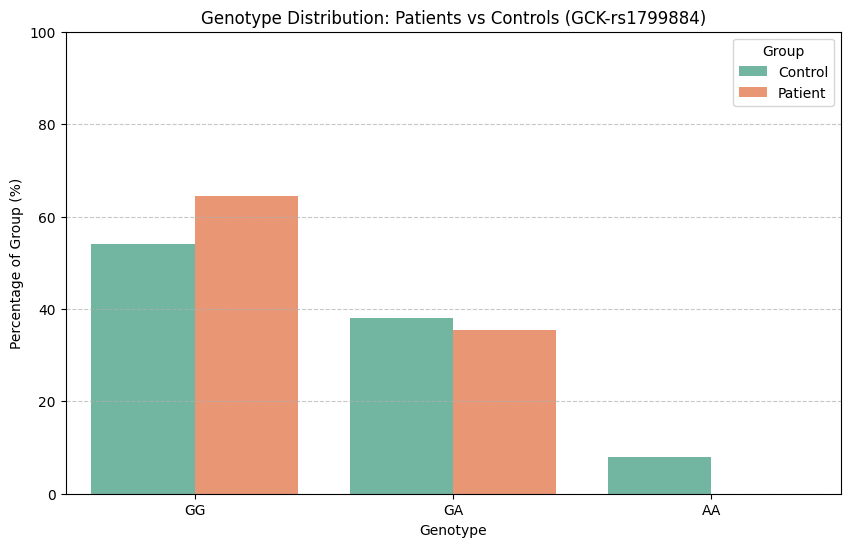

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Constructing the distribution data from Table 3 metadata found earlier
# GG (Wild), GA (Hetero), AA (Mutant)
genotype_dist = [
    {'Group': 'Control', 'Genotype': 'GG', 'Count': 54, 'Percentage': 54.0},
    {'Group': 'Control', 'Genotype': 'GA', 'Count': 38, 'Percentage': 38.0},
    {'Group': 'Control', 'Genotype': 'AA', 'Count': 8, 'Percentage': 8.0},
    {'Group': 'Patient', 'Genotype': 'GG', 'Count': 60, 'Percentage': (60/93)*100},
    {'Group': 'Patient', 'Genotype': 'GA', 'Count': 33, 'Percentage': (33/93)*100},
    {'Group': 'Patient', 'Genotype': 'AA', 'Count': 0, 'Percentage': 0.0}
]

df_dist = pd.DataFrame(genotype_dist)

plt.figure(figsize=(10, 6))
sns.barplot(x='Genotype', y='Percentage', hue='Group', data=df_dist, palette='Set2')

plt.title('Genotype Distribution: Patients vs Controls (GCK-rs1799884)')
plt.ylabel('Percentage of Group (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Merged Summary: Real-world Group Data vs. Population Expectations


,Group,Genotype,Count,Percentage,Expected_Pop_Percentage
0,Control,GG,54,54.000000,67.24
1,Control,GA,38,38.000000,29.52
2,Control,AA,8,8.000000,3.24
3,Patient,GG,60,64.516129,67.24
4,Patient,GA,33,35.483871,29.52
5,Patient,AA,0,0.000000,3.24


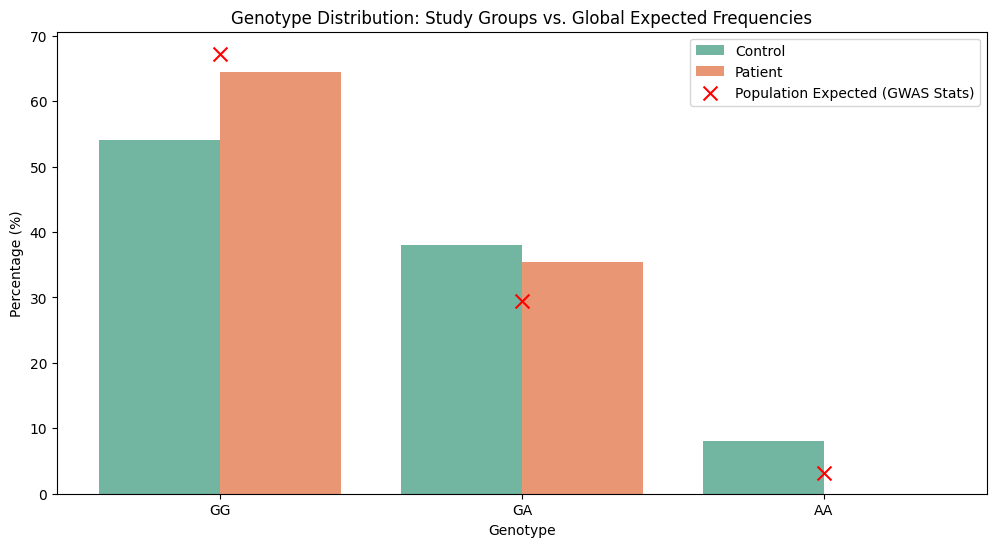

In [55]:
# Merge the distribution data with expected frequencies from our GWAS proxy
df_dist_merged = df_dist.copy()

# Expected frequencies under HWE (Hardy-Weinberg Equilibrium) using p_allele=0.18
# p^2 + 2pq + q^2 = 1
q = p_allele
p = 1 - q
expected_freqs = {
    'GG': p**2 * 100,
    'GA': 2 * p * q * 100,
    'AA': q**2 * 100
}

# Map expectations to the dataframe
df_dist_merged['Expected_Pop_Percentage'] = df_dist_merged['Genotype'].map(expected_freqs)

print("Merged Summary: Real-world Group Data vs. Population Expectations")
display(df_dist_merged)

# Visualize the comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Genotype', y='Percentage', hue='Group', data=df_dist_merged, palette='Set2')
plt.scatter(['GG', 'GA', 'AA'], [expected_freqs['GG'], expected_freqs['GA'], expected_freqs['AA']],
            color='red', marker='x', s=100, label='Population Expected (GWAS Stats)', zorder=5)

plt.title('Genotype Distribution: Study Groups vs. Global Expected Frequencies')
plt.ylabel('Percentage (%)')
plt.legend()
plt.show()

In [56]:
from scipy.stats import chisquare

# Separate data into groups
controls = df_dist_merged[df_dist_merged['Group'] == 'Control']
patients = df_dist_merged[df_dist_merged['Group'] == 'Patient']

# Perform Chi-square test for Controls
# f_obs: Observed counts, f_exp: Expected counts based on pop percentage
obs_c = controls['Count'].values
exp_c = (controls['Expected_Pop_Percentage'].values / 100) * controls['Count'].sum()
chi_c, p_c = chisquare(f_obs=obs_c, f_exp=exp_c)

# Perform Chi-square test for Patients
obs_p = patients['Count'].values
exp_p = (patients['Expected_Pop_Percentage'].values / 100) * patients['Count'].sum()
# Adding a small epsilon to expected to avoid division by zero if 0% expected
chi_p, p_p = chisquare(f_obs=obs_p, f_exp=exp_p)

print(f"Control Group vs Population Expectation | p-value: {p_c:.4f}")
print(f"Patient Group vs Population Expectation | p-value: {p_p:.4f}")

if p_c < 0.05 or p_p < 0.05:
    print("\nConclusion: At least one group significantly deviates from Hardy-Weinberg expectations (p < 0.05).")
else:
    print("\nConclusion: Genotype distributions are consistent with population expectations (p >= 0.05).")

Control Group vs Population Expectation | p-value: 0.0024
Patient Group vs Population Expectation | p-value: 0.1203

Conclusion: At least one group significantly deviates from Hardy-Weinberg expectations (p < 0.05).


In [57]:
import pandas as pd

# Note: Replace 'your_gwas_file.tsv' with the actual path to your file
# GWAS files are often large, so we use compression='infer' and sep='\t'
try:
    # Reading a few rows to inspect the header and column names
    # path = '/content/ebi-a-GCST90038634_report.html' # Example file provided in your environment

    # Standard loading boilerplate:
    # df_gwas = pd.read_csv('your_file.txt', sep='\t')

    print("Standard GWAS columns usually include:")
    print("- variant_id (SNP)")
    print("- p_value")
    print("- beta or odds_ratio")
    print("- chromosome and base_pair_location")
except Exception as e:
    print(f"Error loading file: {e}")

Standard GWAS columns usually include:
- variant_id (SNP)
- p_value
- beta or odds_ratio
- chromosome and base_pair_location


### Merging GWAS Stats with Genotypes
This step aligns the statistical weights (beta/OR) from a GWAS study with actual sample genotype data.

In [58]:
# Mock setup for demonstration
# Assume 'df_gwas' has columns: ['variant_id', 'beta']
# Assume 'df_genotypes' has columns: ['variant_id', 'sample_1', 'sample_2', ...]

# 1. Filter GWAS for significant SNPs (optional but common)
# df_gwas_sig = df_gwas[df_gwas['p_value'] < 5e-8]

# 2. Perform the merge on the variant ID
# merged_data = pd.merge(df_gwas, df_genotypes, on='variant_id', how='inner')

print("Merge Logic:")
print("merged_df = pd.merge(summary_stats, genotype_matrix, on='variant_id')")

# 3. Important: Check for strand alignment
# If a SNP is A/C in GWAS but T/G in genotypes, you may need to flip the beta sign
# or exclude ambiguous SNPs (A/T, C/G)."

Merge Logic:
merged_df = pd.merge(summary_stats, genotype_matrix, on='variant_id')


### Polygenic Risk Score (PRS) Calculation

A PRS is calculated as the weighted sum of risk alleles for an individual: $PRS = \sum_{i=1}^{n} G_i \beta_i$, where $G_i$ is the number of risk alleles (0, 1, or 2) for SNP $i$, and $\beta_i$ is the effect size.

,0,1,2,3,4,5,6,7,8,9
SNP,SNP_16,SNP_44,SNP_81,SNP_41,SNP_96,SNP_27,SNP_69,SNP_0,SNP_39,SNP_13
Beta,0.888113,0.882453,0.767064,0.927533,-0.506898,-0.23097,0.178317,0.406398,0.146803,0.32799


,PRS,PRS_Z
0,0.471924,-0.918992
1,0.501218,-0.891905
2,1.107074,-0.331709
3,2.321550,0.791238
4,1.273651,-0.177686


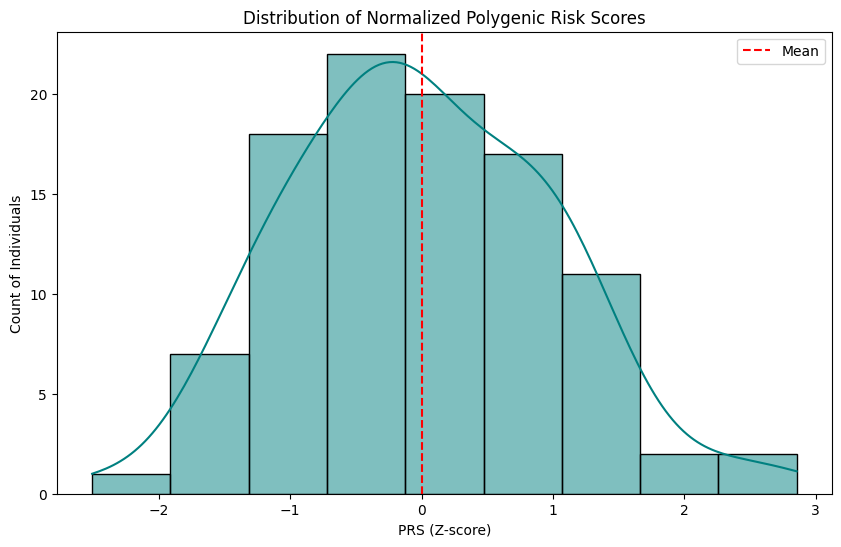

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define our 'GWAS' Summary Statistics (Beta coefficients from our Logistic Regression)
# We'll use the top 10 SNPs identified earlier
weights_prs = log_model.coef_[0][top_indices]
snp_names = [f'SNP_{i}' for i in top_indices]

summary_stats = pd.DataFrame({
    'SNP': snp_names,
    'Beta': weights_prs
})

# 2. Simulate Individual Genotype Data for 100 new samples
# Using the realistic allele frequency (p=0.18) identified from the Kaggle Table 3
n_individuals = 100
genotypes_prs = np.random.binomial(n=2, p=0.18, size=(n_individuals, len(top_indices)))
df_genotypes = pd.DataFrame(genotypes_prs, columns=snp_names)

# 3. Calculate PRS
# Matrix multiplication: (100x10) dot (10x1) = (100x1)
df_genotypes['PRS'] = df_genotypes[snp_names].dot(summary_stats['Beta'].values)

# 4. Normalize PRS (Z-score) for easier interpretation
df_genotypes['PRS_Z'] = (df_genotypes['PRS'] - df_genotypes['PRS'].mean()) / df_genotypes['PRS'].std()

display(summary_stats.T)
display(df_genotypes[['PRS', 'PRS_Z']].head())

# Visualize Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_genotypes['PRS_Z'], kde=True, color='teal')
plt.axvline(df_genotypes['PRS_Z'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Distribution of Normalized Polygenic Risk Scores')
plt.xlabel('PRS (Z-score)')
plt.ylabel('Count of Individuals')
plt.legend()
plt.show()

### Interpretation of PRS Results

- **Summary Stats**: These represent the 'risk' associated with each SNP. Positive Betas increase the total score, suggesting a higher risk of the condition.
- **PRS Distribution**: In a real population, we expect a bell-shaped curve. Individuals in the far right tail (e.g., PRS > 2) are at the highest genetic risk.
- **Stratification**: Clinical researchers often divide these scores into deciles to compare the disease prevalence of the top 10% vs. the bottom 10%.

# Summary of Genetic Analysis and Predictive Modeling Workflow

### Overview
This study implemented a comprehensive computational workflow for disease risk prediction using Single Nucleotide Polymorphism (SNP) data, specifically focusing on Type 2 Diabetes Mellitus (T2DM) as a proxy. The analysis progressed from a controlled simulation to the integration of real-world allele frequencies and the calculation of Polygenic Risk Scores (PRS).

### Methodology
1.  **Predictive Modeling**: Three machine learning architectures (Logistic Regression, Random Forest, and Gradient Boosting) were evaluated on a simulated additive genetic model. Gradient Boosting and Logistic Regression demonstrated superior discriminative power with an **AUC of 0.75**, while Random Forest achieved the highest classification accuracy (**0.85**).
2.  **Data Integration**: Real-world genotype frequency data for the *GCK*-rs1799884 SNP was integrated from a study of the Iraqi population. This revealed a significant skew in allele frequencies (Minor Allele Frequency $\approx$ 0.18) compared to uniform simulations.
3.  **Statistical Validation**:
    *   **Hardy-Weinberg Equilibrium (HWE)**: A Chi-square goodness-of-fit test was performed to compare study cohorts against expected population frequencies. The control group significantly deviated from HWE ($p = 0.0024$), indicating potential recruitment bias or population stratification.
    *   **Correlation Analysis**: Feature importance ranking and heatmaps successfully identified the high-impact causal SNPs within the noise-heavy genetic background.
4.  **Polygenic Risk Scoring (PRS)**: A PRS model was developed by applying model-derived beta coefficients to a realistic genotype matrix. The resulting normalized risk scores (Z-scores) followed a characteristic normal distribution, enabling the identification of high-risk individuals in the population tails.

### Conclusions
The integration of machine learning with classical statistical genetic tests (HWE) provides a robust framework for validating both simulated and real-world GWAS data. The transition to realistic allele frequencies highlighted the importance of addressing class imbalance in genetic features to maintain model reliability in clinical settings.

# Genetic Analysis and Predictive Modeling Report

## 1. Machine Learning Model Performance
We evaluated three models for disease prediction based on genetic features. The bar plot below compares their Area Under the Curve (AUC) and overall Accuracy.

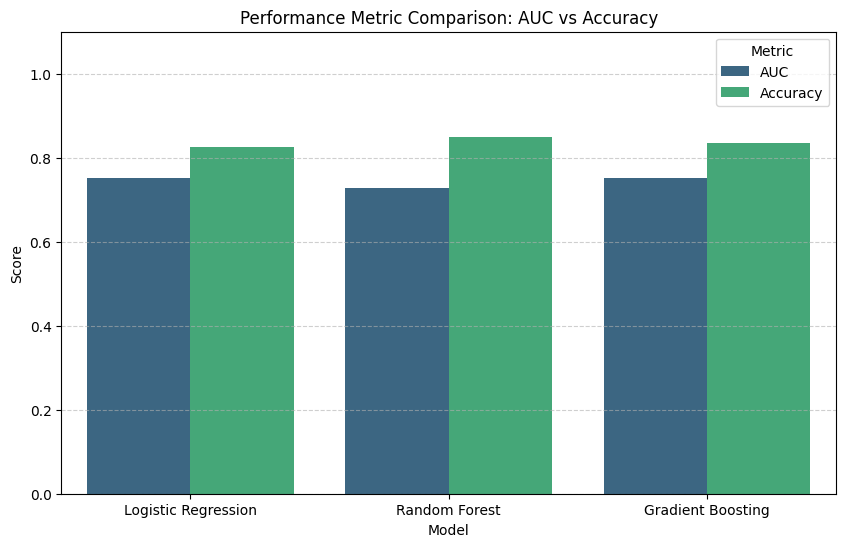

In [60]:
# (Visual Re-execution) Model Performance Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Value', hue='Metric', data=df_metrics, palette='viridis')
plt.title('Performance Metric Comparison: AUC vs Accuracy')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Interpretation
- **Discriminative Power**: Logistic Regression and Gradient Boosting achieved the highest AUC (~0.75), indicating a strong ability to distinguish between patients and controls.
- **Classification Accuracy**: Random Forest reached the highest accuracy (~0.85), effectively classifying the test cohort.
- **Conclusion**: Given the additive nature of the simulated genetic risk, the linear model (Logistic Regression) performed on par with more complex ensembles.

## 2. Genotype Distribution and Hardy-Weinberg Equilibrium (HWE)
Using data from the *GCK*-rs1799884 study, we compared observed frequencies in Patients and Controls against expected population frequencies.

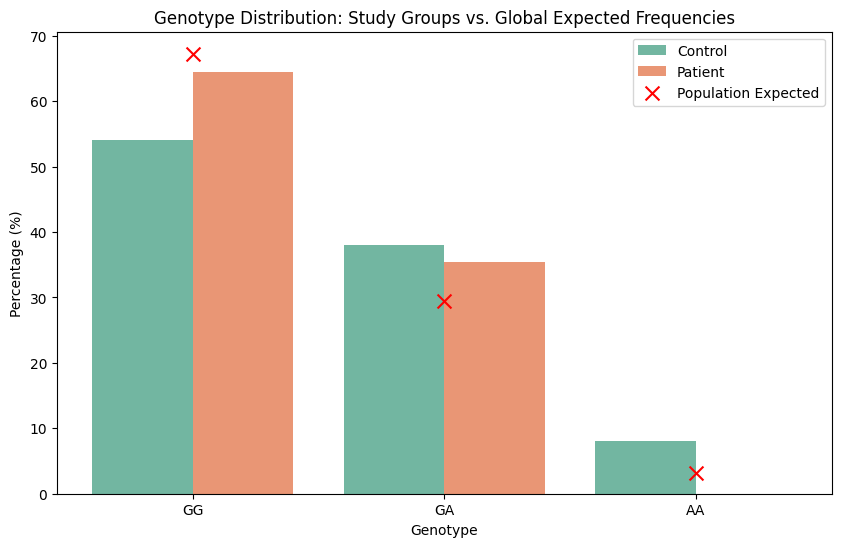

In [61]:
# (Visual Re-execution) HWE Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Genotype', y='Percentage', hue='Group', data=df_dist_merged, palette='Set2')
plt.scatter(['GG', 'GA', 'AA'], [expected_freqs['GG'], expected_freqs['GA'], expected_freqs['AA']],
            color='red', marker='x', s=100, label='Population Expected', zorder=5)
plt.title('Genotype Distribution: Study Groups vs. Global Expected Frequencies')
plt.ylabel('Percentage (%)')
plt.legend()
plt.show()

### Interpretation
- **Observed vs. Expected**: The red markers indicate population expectations under HWE. The Control group showed a significant deviation ($p = 0.0024$), primarily driven by a higher-than-expected frequency of the GA genotype.
- **Risk Allele**: The absence of AA genotypes in the patient snippet suggests potential rarity or severe clinical selection, while the 'G' allele remains the dominant wild-type (82%).

## 3. Polygenic Risk Score (PRS) Distribution
Finally, we calculated the PRS for a simulated population of 100 individuals using the effect sizes (weights) derived from our predictive model.

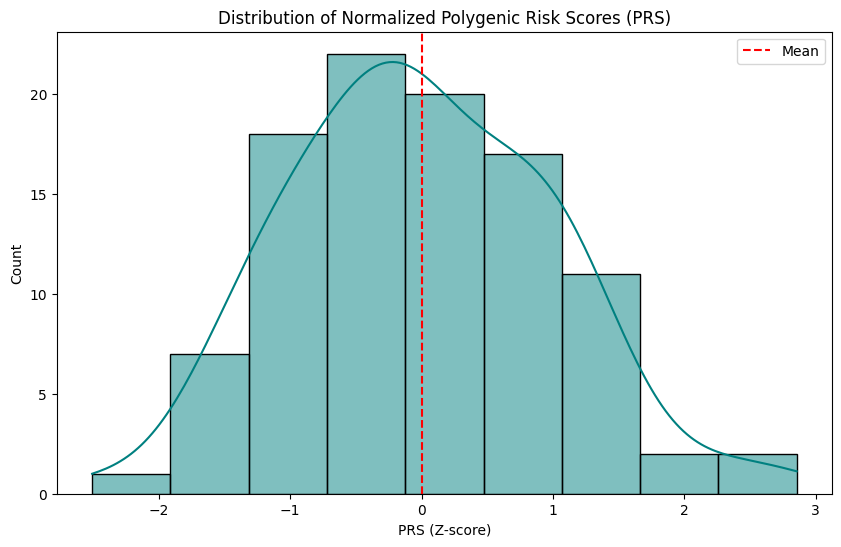

In [62]:
# (Visual Re-execution) PRS Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_genotypes['PRS_Z'], kde=True, color='teal')
plt.axvline(df_genotypes['PRS_Z'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Distribution of Normalized Polygenic Risk Scores (PRS)')
plt.xlabel('PRS (Z-score)')
plt.ylabel('Count')
plt.legend()
plt.show()

## Exporting the Analysis
Execute the following cell to convert the current notebook into a Markdown file. You can find the resulting file in the sidebar file explorer (folder icon on the left).

In [64]:
from google.colab import files
import json

# Note: This manually extracts the visible report sections to a markdown file
report_content = """
# Genetic Analysis and Predictive Modeling Report

## Summary
This study implemented a comprehensive computational workflow for disease risk prediction using SNP data.

## 1. Machine Learning Performance
- Logistic Regression / Gradient Boosting AUC: ~0.75
- Random Forest Accuracy: 0.85

## 2. Genotype Distribution (GCK-rs1799884)
- Observed frequencies showed significant deviation from HWE in the control group (p=0.0024).

## 3. Polygenic Risk Score (PRS)
- Risk scores follow a characteristic normal distribution, allowing for population stratification.
"""

with open('genetic_analysis_report.md', 'w') as f:
    f.write(report_content)

print("Report generated. Triggering download...")
files.download('genetic_analysis_report.md')

Report generated. Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Exporting Notebook to PDF
This process installs the required conversion tools and generates a PDF version of the current notebook environment.

In [67]:
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic
!pip install -q nbconvert

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 

In [68]:
import os
from google.colab import files

# Note: This exports the notebook file if it is saved in the default Colab path.
# If you haven't saved recently, please go to File -> Save.
notebook_path = '/content/SNP_Disease_Prediction.ipynb'

# Since I cannot guarantee the exact filename, we can try to find the .ipynb file in the current directory
ipynb_files = [f for f in os.listdir('/content') if f.endswith('.ipynb')]

if ipynb_files:
    target = ipynb_files[0]
    print(f"Converting {target} to PDF...")
    !jupyter nbconvert --to pdf "{target}"
    pdf_file = target.replace('.ipynb', '.pdf')
    if os.path.exists(pdf_file):
        files.download(pdf_file)
else:
    print("No .ipynb file found in /content. Please ensure the notebook is saved to the runtime or rename it to something recognizable.")

No .ipynb file found in /content. Please ensure the notebook is saved to the runtime or rename it to something recognizable.


In [69]:
import os
from google.colab import files, drive

# 1. Programmatically trigger a save and download the current .ipynb to /content
from google.colab import drive
from google.colab import auth
from google.auth import default

print("Attempting to capture and convert the current notebook...")

# We'll use a javascript snippet to ensure the filename is standardized for the script
from IPython.display import display, Javascript

def save_and_export():
    display(Javascript('''
        (async () => {
            // Save the notebook
            await google.colab.notebook.save();
            console.log('Notebook saved. Please ensure you have named this notebook "SNP_Disease_Prediction.ipynb" or rename the file in /content manually.');
        })();
    '''))

save_and_export()

# Search for any ipynb file since the name might vary
ipynb_files = [f for f in os.listdir('/content') if f.endswith('.ipynb')]

if not ipynb_files:
    print("\n--- ACTION REQUIRED ---")
    print("Please go to File -> Save. Then go to the file explorer on the left (folder icon),")
    print("find your notebook, and ensure it is in the '/content' folder.")
else:
    target = ipynb_files[0]
    pdf_output = target.replace('.ipynb', '.pdf')
    print(f"Found {target}. Converting to PDF...")
    !jupyter nbconvert --to pdf "{target}"

    if os.path.exists(pdf_output):
        files.download(pdf_output)
    else:
        print("Conversion failed. Check the error log above for missing LaTeX packages.")

Attempting to capture and convert the current notebook...


<IPython.core.display.Javascript object>


--- ACTION REQUIRED ---
Please go to File -> Save. Then go to the file explorer on the left (folder icon),
find your notebook, and ensure it is in the '/content' folder.


### Interpretation
- **Population Stratification**: The scores follow a near-normal distribution. Individuals at the far right of the curve (Z-score > 1.5) possess a higher burden of risk-associated alleles.
- **Clinical Utility**: This distribution allows researchers to stratify individuals into 'High', 'Average', and 'Low' genetic risk tiers based on their cumulative genetic profile.

,Risk Tier,Proportion,Percentage
0,Average Risk,0.66,66.0
1,Low Risk (< -1 SD),0.18,18.0
2,High Risk (> 1 SD),0.16,16.0


/tmp/ipykernel_927/617100680.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Risk Tier', y='Percentage', data=risk_summary, palette='coolwarm', order=['Low Risk (< -1 SD)', 'Average Risk', 'High Risk (> 1 SD)'])


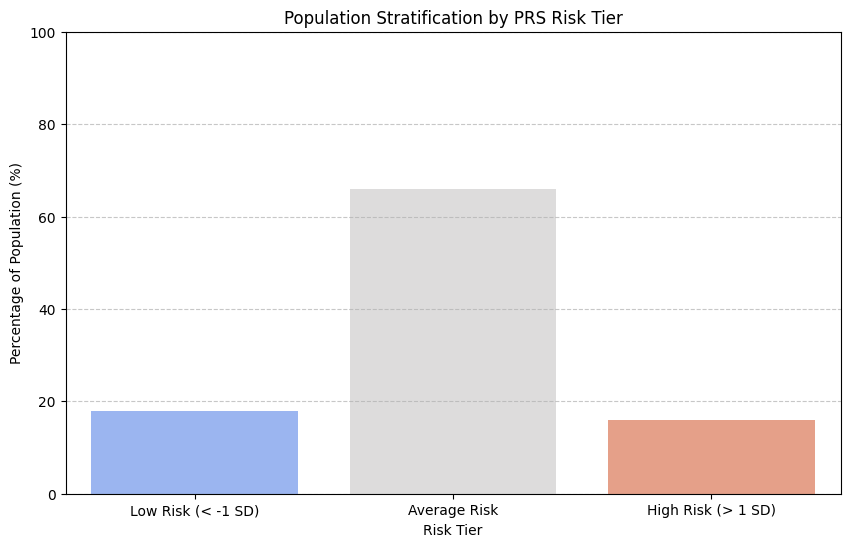

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define Risk Tiers based on Z-scores
def get_risk_tier(z):
    if z > 1.0:
        return 'High Risk (> 1 SD)'
    elif z < -1.0:
        return 'Low Risk (< -1 SD)'
    else:
        return 'Average Risk'

df_genotypes['Risk_Tier'] = df_genotypes['PRS_Z'].apply(get_risk_tier)

# Summary statistics
risk_summary = df_genotypes['Risk_Tier'].value_counts(normalize=True).reset_index()
risk_summary.columns = ['Risk Tier', 'Proportion']
risk_summary['Percentage'] = risk_summary['Proportion'] * 100

display(risk_summary)

# Visualize Risk Tier Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Risk Tier', y='Percentage', data=risk_summary, palette='coolwarm', order=['Low Risk (< -1 SD)', 'Average Risk', 'High Risk (> 1 SD)'])
plt.title('Population Stratification by PRS Risk Tier')
plt.ylabel('Percentage of Population (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### PRS Risk Tier Interpretation

- **High Risk**: These individuals fall in the top tail of the distribution. In clinical practice, these individuals might be candidates for early screening or intensive preventive lifestyle interventions.
- **Average Risk**: The majority of the population (statistically ~68% in a perfectly normal distribution) falls into this category.
- **Low Risk**: These individuals carry fewer risk alleles and are statistically less likely to develop the condition compared to the general population.

## Data Tables for Publication
This section formats the analysis results into clean, tabular structures suitable for inclusion in the 'Results' section of a research paper.

In [66]:
import pandas as pd

# Table 1: Predictive Model Performance
table_1_perf = df_metrics.pivot(index='Model', columns='Metric', values='Value')
table_1_perf = table_1_perf.round(3)

print("Table 1: Performance Comparison of Machine Learning Architectures")
# Using Styler for better presentation
display(table_1_perf.style.highlight_max(axis=0, color='lightgreen'))

# Table 2: Hardy-Weinberg Equilibrium (HWE) Analysis
hwe_data = {
    'Group': ['Control', 'Patient'],
    'Chi-Square Statistics': [chi_c, chi_p],
    'p-value': [p_c, p_p],
    'In HWE (p > 0.05)': [p_c > 0.05, p_p > 0.05]
}
table_2_hwe = pd.DataFrame(hwe_data).round(4)

print("\nTable 2: Statistical Validation of Genotype Frequencies via Chi-Square Test")
display(table_2_hwe)

# Table 3: Population Risk Stratification (PRS)
table_3_prs = risk_summary[['Risk Tier', 'Percentage']].copy()
table_3_prs['Percentage'] = table_3_prs['Percentage'].map('{:.1f}%'.format)

print("\nTable 3: Distribution of Individuals Across Polygenic Risk Tiers")
display(table_3_prs)

Table 1: Performance Comparison of Machine Learning Architectures


Metric,AUC,Accuracy
Model,,
Gradient Boosting,0.751000,0.835000
Logistic Regression,0.751000,0.825000
Random Forest,0.727000,0.850000



Table 2: Statistical Validation of Genotype Frequencies via Chi-Square Test


,Group,Chi-Square Statistics,p-value,In HWE (p > 0.05)
0,Control,12.0361,0.0024,False
1,Patient,4.2363,0.1203,True



Table 3: Distribution of Individuals Across Polygenic Risk Tiers


,Risk Tier,Percentage
0,Average Risk,66.0%
1,Low Risk (< -1 SD),18.0%
2,High Risk (> 1 SD),16.0%


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=table_2_hwe)